# ICT665 Assignment - Genetic Algorithm Feature Selection and Polynomial Regression 

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assume df is your DataFrame with numerical, scaled predictors
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Feature'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df.sort_values(by='VIF', ascending=False)

# 1. Setup Models
degree = 2
models = {
    'LinearRegression': (LinearRegression(), {}),
    'Lasso': (Lasso(), {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}),
    'Ridge': (Ridge(), {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}),
    'ElasticNet': (ElasticNet(), {"alpha": [0.1, 1.0, 5.0], "l1_ratio": [0.5]}),
    'RandomForest': (RandomForestRegressor(), {"n_estimators": [100, 200], "max_depth": [None, 10]})
}


def get_performance(X_train, y_train, X_test, y_test, model, config):
    grid = GridSearchCV(model, config, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    predictions = best_model.predict(X_test)
    
    correlation = np.corrcoef(y_test, predictions)[0, 1]
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    return pd.Series({
        "Best Config": best_params,
        "Correlation": correlation,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


In [2]:
data = pd.read_csv("/Users/rsoedarnadi/Documents/Github/mic-peptide-assignment/Data.csv")
data['TARGET'] = data['TARGET'].str.replace(r'\s+', '', regex=True).astype(float)
X = data.drop("TARGET", axis=1)
y = data["TARGET"]
print("Peptide dataset:\n",X.shape[0],"Records\n",X.shape[1],"Features")
data.tail()

Peptide dataset:
 11266 Records
 39 Features


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F31,F32,F33,F34,F35,F36,F37,F38,F39,TARGET
11261,0.000000,0.100000,0.400000,0.250000,0.250000,0.300000,0.200000,0.450000,0.150000,0.050000,...,0.000000,0.0,0.1,0.200000,0.100000,0.400000,0.100000,0.200000,0.000000,1.894319
11262,0.076923,0.230769,0.230769,0.076923,0.000000,0.307692,0.153846,0.307692,0.000000,0.153846,...,0.307692,0.0,0.0,0.153846,0.076923,0.153846,0.307692,0.153846,0.000000,1.881124
11263,0.250000,0.194444,0.361111,0.361111,0.222222,0.138889,0.305556,0.277778,0.083333,0.055556,...,0.222222,0.0,0.0,0.222222,0.111111,0.305556,0.222222,0.305556,0.222222,3.051589
11264,0.100000,0.100000,0.350000,0.350000,0.200000,0.200000,0.250000,0.200000,0.200000,0.150000,...,0.200000,0.0,0.0,0.300000,0.400000,0.150000,0.200000,0.100000,0.000000,17.025972
11265,0.100000,0.100000,0.350000,0.300000,0.250000,0.100000,0.200000,0.250000,0.100000,0.150000,...,0.200000,0.0,0.0,0.100000,0.450000,0.100000,0.200000,0.100000,0.000000,11.016521


In [3]:
print(data.isna().sum())

F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
F9        0
F10       0
F11       0
F12       0
F13       0
F14       0
F15       0
F16       0
F17       0
F18       0
F19       0
F20       0
F21       0
F22       0
F23       0
F24       0
F25       0
F26       0
F27       0
F28       0
F29       0
F30       0
F31       0
F32       0
F33       0
F34       0
F35       0
F36       0
F37       0
F38       0
F39       0
TARGET    0
dtype: int64


## Data Manipulation and Handling Multicollinearity

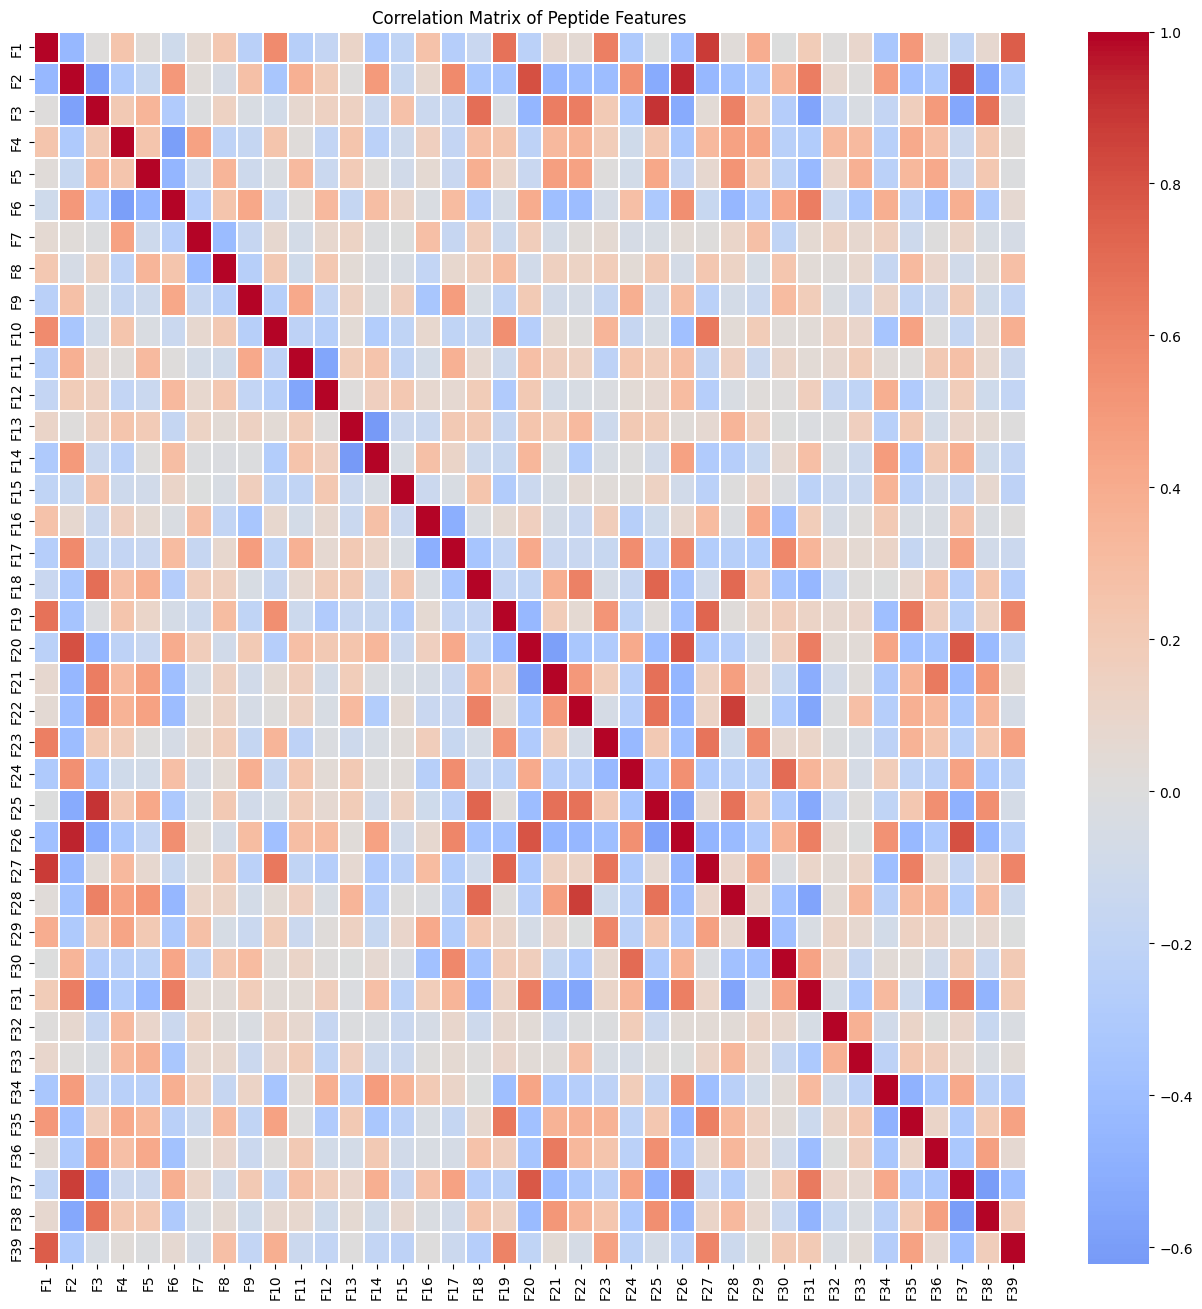

Variance Inflation Factor (VIF) for each feature:
   Feature           VIF
0       F1  9.007199e+15
29     F30  9.007199e+15
25     F26  9.007199e+15
38     F39  9.007199e+15
1       F2  9.007199e+15
28     F29  4.503600e+15
13     F14  4.503600e+15
20     F21  4.503600e+15
23     F24  4.503600e+15
36     F37  4.503600e+15
12     F13  4.503600e+15
19     F20  4.503600e+15
22     F23  3.002400e+15
11     F12  3.002400e+15
10     F11  3.002400e+15
24     F25  1.801440e+15
16     F17  7.977583e+01
2       F3  7.959737e+01
30     F31  7.292198e+01
5       F6  6.611769e+01
7       F8  3.648056e+01
26     F27  3.297240e+01
17     F18  2.751467e+01
27     F28  2.376121e+01
8       F9  2.369823e+01
15     F16  2.044152e+01
21     F22  2.010971e+01
4       F5  1.928404e+01
33     F34  1.643057e+01
37     F38  1.415679e+01
3       F4  1.287385e+01
18     F19  1.216381e+01
34     F35  1.079765e+01
6       F7  9.762366e+00
35     F36  8.365550e+00
9      F10  6.357120e+00
14     F15  5.293057e+00


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = X.corr()

plt.figure(figsize=(16, 16)) 
sns.heatmap(
    correlation_matrix, 
    cmap='coolwarm',
    fmt='.2f',          
    linewidths=0.1,
    center=0  
)
# 4. Add a title and display the plot
plt.title("Correlation Matrix of Peptide Features")
plt.show()

vif_data = calculate_vif(X)
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Dropping features: ['F20', 'F25', 'F26', 'F27', 'F28', 'F30', 'F37', 'F39']


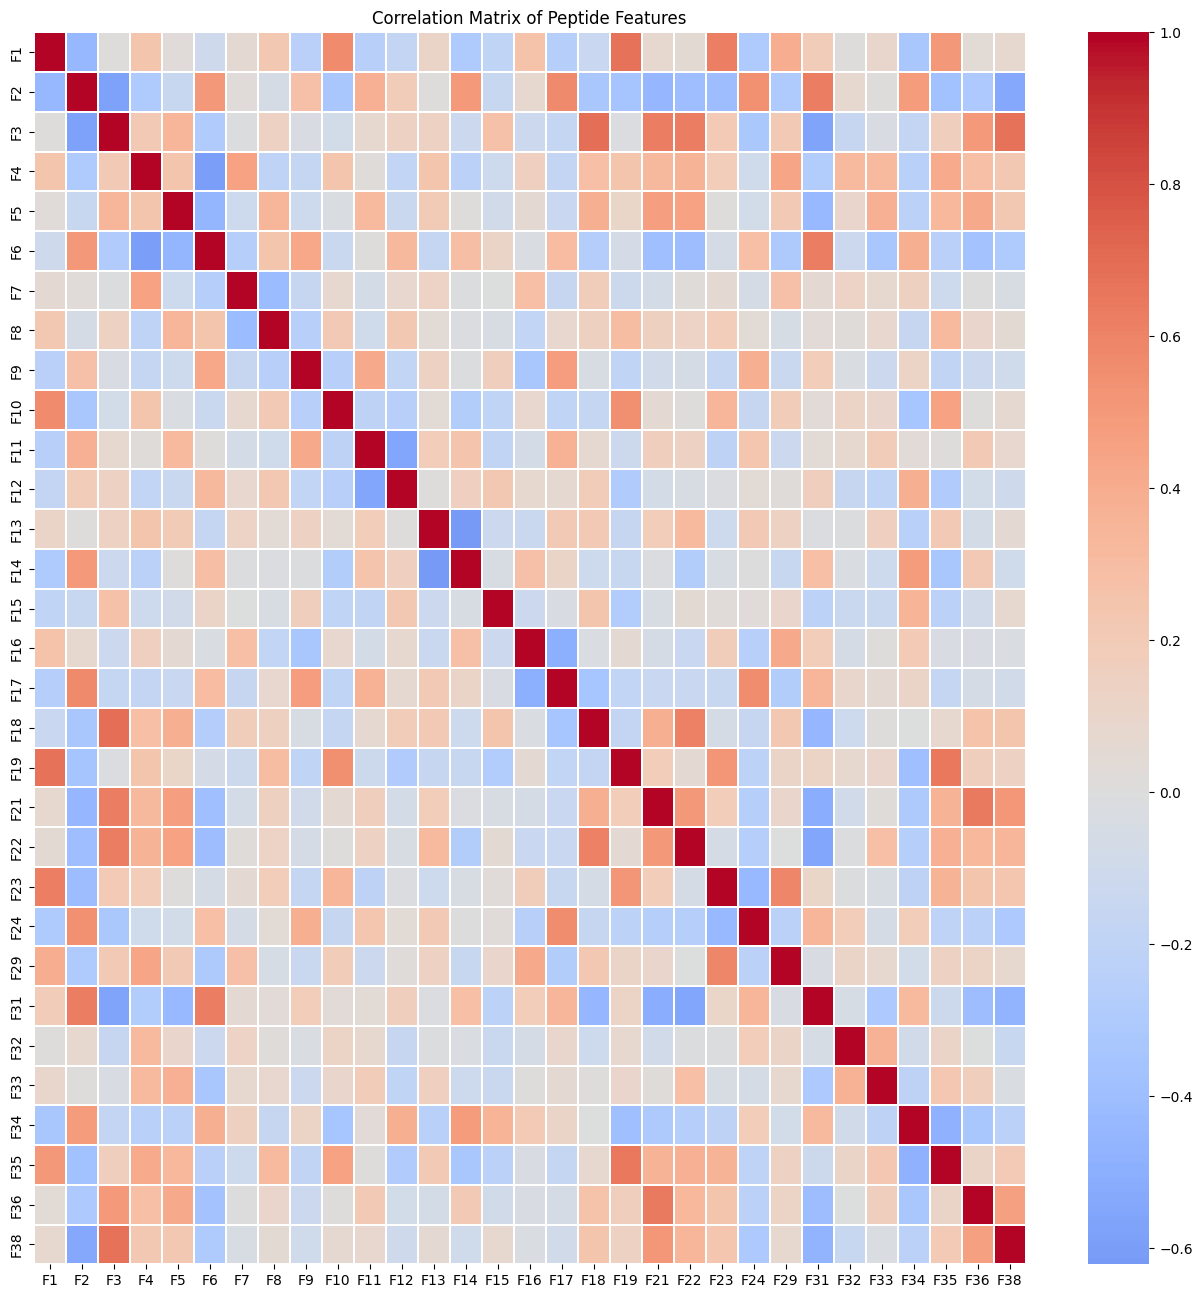

Variance Inflation Factor (VIF) for each feature:
   Feature         VIF
1       F2  176.331746
10     F11   85.901104
16     F17   73.154945
2       F3   71.694098
11     F12   71.196156
24     F31   67.573027
5       F6   64.459349
12     F13   45.384580
13     F14   36.543742
7       F8   35.156538
17     F18   25.498470
8       F9   22.331687
0       F1   20.353374
4       F5   17.300983
27     F34   16.285763
15     F16   15.420941
21     F23   15.293587
23     F29   13.108469
19     F21   13.019565
20     F22   11.947487
3       F4   11.736585
30     F38   11.435632
18     F19   10.797738
28     F35    9.896718
22     F24    9.519937
6       F7    9.203382
29     F36    8.172194
9      F10    5.658292
14     F15    4.792075
26     F33    3.322398
25     F32    1.877077


In [5]:
# 5. Drop features with high correlation (r > 0.8)
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(np.absolute(upper[column]) > 0.7)]
print(f"Dropping features: {to_drop}")
X = X.drop(columns=to_drop)
correlation_matrix = X.corr()

plt.figure(figsize=(16, 16)) 
sns.heatmap(
    correlation_matrix, 
    cmap='coolwarm',
    fmt='.2f',          
    linewidths=0.1,
    center=0  
)
# 4. Add a title and display the plot
plt.title("Correlation Matrix of Peptide Features")
plt.show()

vif_data = calculate_vif(X)
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

In [19]:
results_list = []

for model_name, (model_obj, config) in models.items():
    print(f"Now training and tuning: {model_name}...")
    
    performance_metrics = get_performance(X_train, y_train, X_test, y_test, model_obj, config)
    performance_metrics.name = model_name
    results_list.append(performance_metrics)

final_report = pd.DataFrame(results_list)
print("\nFinal Performance Report:")
print(final_report)

Now training and tuning: LinearRegression...
Now training and tuning: Lasso...
Now training and tuning: Ridge...
Now training and tuning: ElasticNet...
Now training and tuning: RandomForest...

Final Performance Report:
                                               Best Config  Correlation  \
LinearRegression                                        {}     0.187993   
Lasso                                      {'alpha': 0.01}     0.189064   
Ridge                                       {'alpha': 1.0}     0.189289   
ElasticNet                 {'alpha': 0.1, 'l1_ratio': 0.5}     0.170046   
RandomForest      {'max_depth': None, 'n_estimators': 100}     0.706622   

                        MAE       RMSE        R2  
LinearRegression  46.167189  75.290327  0.003254  
Lasso             46.042876  75.181369  0.006137  
Ridge             46.086533  75.195514  0.005763  
ElasticNet        46.501834  74.871970  0.014301  
RandomForest      26.154997  55.542895  0.457546  


In [20]:
# Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

final_report = pd.DataFrame(results_list)
print("Training Polynomial Degree 2...")
poly_results = get_performance(X_train_poly, y_train, X_test_poly, y_test, LinearRegression(), {})
poly_results.name = "Polynomial_Deg2"
final_report = pd.concat([final_report, poly_results.to_frame().T])
print("\nUpdated Performance Report with Polynomial Regression:")
print(final_report)

Training Polynomial Degree 2...

Updated Performance Report with Polynomial Regression:
                                               Best Config Correlation  \
LinearRegression                                        {}    0.187993   
Lasso                                      {'alpha': 0.01}    0.189064   
Ridge                                       {'alpha': 1.0}    0.189289   
ElasticNet                 {'alpha': 0.1, 'l1_ratio': 0.5}    0.170046   
RandomForest      {'max_depth': None, 'n_estimators': 100}    0.706622   
Polynomial_Deg2                                         {}    0.371758   

                        MAE       RMSE        R2  
LinearRegression  46.167189  75.290327  0.003254  
Lasso             46.042876  75.181369  0.006137  
Ridge             46.086533  75.195514  0.005763  
ElasticNet        46.501834   74.87197  0.014301  
RandomForest      26.154997  55.542895  0.457546  
Polynomial_Deg2   46.010492  77.395626 -0.053268  


In [39]:
final_report = final_report.sort_values(by='R2', ascending=False)
final_report.to_csv("model_performance_report.csv", index=True)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from random import randint
from sklearn.metrics import r2_score
from itertools import product
import pandas as pd

def initialization_of_population(size, n_feat):
    population = []
    for i in range(size):
        # Create a boolean mask for features
        chromosome = np.ones(n_feat, dtype=bool)     
        chromosome[:int(0.3 * n_feat)] = False             
        np.random.shuffle(chromosome)
        population.append(chromosome)
    return population

def selection(pop_after_fit, n_parents):
    return pop_after_fit[:n_parents]

import random

def crossover(pop_after_sel, crossover_prob):
    pop_nextgen = []
    for i in range(0, len(pop_after_sel) - 1, 2):
        child_1, child_2 = pop_after_sel[i], pop_after_sel[i+1]
        if random.random() < crossover_prob:
            cut = len(child_1) // 2
            new_child1 = np.concatenate((child_1[:cut], child_2[cut:]))
            new_child2 = np.concatenate((child_2[:cut], child_1[cut:]))
            pop_nextgen.extend([new_child1, new_child2])
        else:
            pop_nextgen.extend([child_1, child_2]) 
    return pop_nextgen

def mutation(pop_after_cross, mutation_rate, n_feat):   
    mutation_range = int(mutation_rate * n_feat)
    pop_next_gen = []
    for chromo in pop_after_cross:
        new_chromo = chromo.copy()
        for _ in range(max(1, mutation_range)):
            pos = randint(0, n_feat - 1)
            new_chromo[pos] = not new_chromo[pos]
        pop_next_gen.append(new_chromo)
    return pop_next_gen

def fitness_score(population, model, X_train, Y_train, X_test, Y_test):
    fitness_results = [] # To store all metrics per chromosome
    
    for chromosome in population:
        if not any(chromosome):
            # Penalize empty feature sets
            fitness_results.append({
                'r2': -np.inf, 'mae': np.inf, 'rmse': np.inf, 'corr': -1
            })
            continue
        
        # Handle both DataFrame and Numpy array indexing
        X_tr_sub = X_train.iloc[:, chromosome] if hasattr(X_train, 'iloc') else X_train[:, chromosome]
        X_te_sub = X_test.iloc[:, chromosome] if hasattr(X_test, 'iloc') else X_test[:, chromosome]
        
        # Train and Predict
        model.fit(X_tr_sub, Y_train)         
        predictions = model.predict(X_te_sub)
        
        # Calculate Metrics
        # Handle edge case where correlation might fail if predictions are constant
        try:
            correlation = np.corrcoef(Y_test, predictions)[0, 1]
            if np.isnan(correlation): correlation = 0
        except:
            correlation = 0
            
        mae = mean_absolute_error(Y_test, predictions)
        rmse = np.sqrt(mean_squared_error(Y_test, predictions))
        r2 = r2_score(Y_test, predictions)
        
        # Store as a dictionary
        fitness_results.append({
            'r2': r2, 
            'mae': mae, 
            'rmse': rmse, 
            'corr': correlation
        })
        
    scores_for_sorting = np.array([res['r2'] for res in fitness_results])
    population = np.array(population) 
    
    inds = np.argsort(scores_for_sorting)[::-1]
    
    sorted_metrics = [fitness_results[i] for i in inds]
    sorted_population = list(population[inds, :])
    
    return sorted_metrics, sorted_population

def run_genetic_evolution(model, size, n_parents, mutation_rate, n_gen, crossover_prob, X_train, X_test, Y_train, Y_test):
    n_feat = X_train.shape[1]
    
    population_nextgen = initialization_of_population(size, n_feat)
    
    for i in range(n_gen):
        # Using the dictionary-based fitness_score from the previous step
        metrics_list, pop_after_fit = fitness_score(population_nextgen, model, X_train, Y_train, X_test, Y_test)
        
        # Evolution steps
        pop_after_sel = selection(pop_after_fit, n_parents)
        pop_after_cross = crossover(pop_after_sel, crossover_prob)
        population_nextgen = mutation(pop_after_cross, mutation_rate, n_feat)
        
    # Return the absolute best from the final generation
    # metrics_list[0] contains {'r2': ..., 'mae': ..., 'rmse': ..., 'corr': ...}
    return pop_after_fit[0], metrics_list[0]


def ga_grid_search(model, X_train, X_test, Y_train, Y_test, param_grid):
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = [dict(zip(keys, v)) for v in product(*values)]
    
    results_list = []
    global_best_r2 = -float('inf')
    global_best_chromo = None
    
    print(f"Starting Grid Search for {len(combinations)} combinations...")
    
    for i, params in enumerate(combinations):
        # run_genetic_evolution now returns: (best_chromo, best_metrics_dict)
        best_chromo, metrics = run_genetic_evolution(
            model=model,
            size= 80,
            n_parents= 80 // 2,
            mutation_rate=params['mutation_rate'],
            crossover_prob=params['crossover_prob'],
            n_gen=params['n_gen'],
            X_train=X_train, X_test=X_test, Y_train=Y_train, Y_test=Y_test
        )
        
        # Track the best chromosome across ALL grid combinations
        if metrics['r2'] > global_best_r2:
            global_best_r2 = metrics['r2']
            global_best_chromo = best_chromo

        
        # Build the result row for the DataFrame
        entry = {**params, **metrics} # Merges params and metrics dictionaries
        results_list.append(entry)
        
        print(f"Config {i+1}/{len(combinations)}: R2 = {metrics['r2']:.4f}")
        
    # Return 1. The full table, 2. The best mask, 3. The best metrics
    return pd.DataFrame(results_list).sort_values(by='r2', ascending=False), global_best_chromo

ga_config = {
    'n_gen': [3, 5, 10],
    'mutation_rate': [0.1, 0.2],
    'crossover_prob': [0.5, 0.8]
}

In [22]:
best_linear = LinearRegression()
ga_metrics_linear, best_mask_linear = ga_grid_search(best_linear, X_train, X_test, y_train, y_test, ga_config)
print("GA Metrics for Linear Regression:\n", ga_metrics_linear)
print("Number of features selected:", np.sum(best_mask_linear))
print("Selected features:\n", X_train.columns[best_mask_linear])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.0197
Config 2/12: R2 = 0.0162
Config 3/12: R2 = 0.0211
Config 4/12: R2 = 0.0243
Config 5/12: R2 = 0.0213
Config 6/12: R2 = 0.0203
Config 7/12: R2 = 0.0195
Config 8/12: R2 = 0.0200
Config 9/12: R2 = 0.0241
Config 10/12: R2 = 0.0213
Config 11/12: R2 = 0.0264
Config 12/12: R2 = 0.0293
GA Metrics for Linear Regression:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
11     10            0.2             0.8  0.029321  46.154090  74.299328   
10     10            0.2             0.5  0.026385  46.478115  74.411588   
3       3            0.2             0.8  0.024286  45.621765  74.491763   
8      10            0.1             0.5  0.024083  45.676765  74.499509   
4       5            0.1             0.5  0.021335  46.906599  74.604332   
9      10            0.1             0.8  0.021281  46.397386  74.606392   
2       3            0.2             0.5  0.021143  46.614589  74.611657   
5       5 

In [27]:
best_rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
ga_metrics_rf, best_mask_rf = ga_grid_search(best_rf, X_train, X_test, y_train, y_test, ga_config)
print("GA Metrics for Random Forest:\n", ga_metrics_rf)
print("Number of features selected:", np.sum(best_mask_rf))
print("Selected features:\n", X_train.columns[best_mask_rf])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.5051
Config 2/12: R2 = 0.5136
Config 3/12: R2 = 0.5047
Config 4/12: R2 = 0.5054
Config 5/12: R2 = 0.5083
Config 6/12: R2 = 0.5042
Config 7/12: R2 = 0.4999
Config 8/12: R2 = 0.5071
Config 9/12: R2 = 0.5023
Config 10/12: R2 = 0.5153
Config 11/12: R2 = 0.5003
Config 12/12: R2 = 0.5022
GA Metrics for Random Forest:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
9      10            0.1             0.8  0.515284  26.021944  52.503791   
1       3            0.1             0.8  0.513605  25.450531  52.594642   
4       5            0.1             0.5  0.508264  25.471404  52.882604   
7       5            0.2             0.8  0.507090  25.745673  52.945702   
3       3            0.2             0.8  0.505417  25.761165  53.035520   
0       3            0.1             0.5  0.505094  25.566923  53.052795   
2       3            0.2             0.5  0.504660  25.690867  53.076076   
5       5     

In [28]:
best_lasso = Lasso(alpha=0.01)
ga_metrics_lasso, best_mask_lasso = ga_grid_search(best_lasso, X_train, X_test, y_train, y_test, ga_config)
print("GA Metrics for Lasso:\n", ga_metrics_lasso)
print("Number of features selected:", np.sum(best_mask_lasso))
print("Selected features:\n", X_train.columns[best_mask_lasso])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.0189
Config 2/12: R2 = 0.0231
Config 3/12: R2 = 0.0224
Config 4/12: R2 = 0.0288
Config 5/12: R2 = 0.0258
Config 6/12: R2 = 0.0199
Config 7/12: R2 = 0.0237
Config 8/12: R2 = 0.0200
Config 9/12: R2 = 0.0286
Config 10/12: R2 = 0.0195
Config 11/12: R2 = 0.0207
Config 12/12: R2 = 0.0215
GA Metrics for Lasso:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
3       3            0.2             0.8  0.028776  46.307646  74.320191   
8      10            0.1             0.5  0.028551  46.540961  74.328784   
4       5            0.1             0.5  0.025768  46.359570  74.435187   
6       5            0.2             0.5  0.023656  46.302705  74.515816   
1       3            0.1             0.8  0.023098  46.424898  74.537109   
2       3            0.2             0.5  0.022393  46.109397  74.564012   
11     10            0.2             0.8  0.021496  46.530270  74.598193   
10     10            0

In [24]:
best_ridge = Ridge(alpha=0.1)
ga_metrics_ridge, best_mask_ridge = ga_grid_search(best_ridge, X_train, X_test, y_train, y_test, ga_config)
print("GA Metrics for Ridge:\n", ga_metrics_ridge)
print("Number of features selected:", np.sum(best_mask_ridge))
print("Selected features:\n", X_train.columns[best_mask_ridge])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.0144
Config 2/12: R2 = 0.0190
Config 3/12: R2 = 0.0237
Config 4/12: R2 = 0.0217
Config 5/12: R2 = 0.0234
Config 6/12: R2 = 0.0210
Config 7/12: R2 = 0.0210
Config 8/12: R2 = 0.0266
Config 9/12: R2 = 0.0148
Config 10/12: R2 = 0.0286
Config 11/12: R2 = 0.0211
Config 12/12: R2 = 0.0222
GA Metrics for Ridge:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
9      10            0.1             0.8  0.028574  45.850964  74.327914   
7       5            0.2             0.8  0.026561  45.960647  74.404882   
2       3            0.2             0.5  0.023672  46.535036  74.515212   
4       5            0.1             0.5  0.023416  46.932411  74.524966   
11     10            0.2             0.8  0.022218  46.475384  74.570668   
3       3            0.2             0.8  0.021747  46.692140  74.588625   
10     10            0.2             0.5  0.021103  46.363664  74.613157   
5       5            0

In [25]:
best_elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)
ga_metrics_elasticnet, best_mask_elasticnet = ga_grid_search(best_elasticnet, X_train, X_test, y_train, y_test, ga_config)
print("GA Metrics for ElasticNet:\n", ga_metrics_elasticnet)
print("Number of features selected:", np.sum(best_mask_elasticnet))
print("Selected features:\n", X_train.columns[best_mask_elasticnet])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.0145
Config 2/12: R2 = 0.0143
Config 3/12: R2 = 0.0136
Config 4/12: R2 = 0.0142
Config 5/12: R2 = 0.0144
Config 6/12: R2 = 0.0151
Config 7/12: R2 = 0.0149
Config 8/12: R2 = 0.0155
Config 9/12: R2 = 0.0150
Config 10/12: R2 = 0.0158
Config 11/12: R2 = 0.0109
Config 12/12: R2 = 0.0138
GA Metrics for ElasticNet:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
9      10            0.1             0.8  0.015824  46.431936  74.814079   
7       5            0.2             0.8  0.015462  46.456300  74.827841   
5       5            0.1             0.8  0.015082  46.477589  74.842277   
8      10            0.1             0.5  0.015013  46.468661  74.844920   
6       5            0.2             0.5  0.014899  46.457707  74.849229   
0       3            0.1             0.5  0.014503  46.496081  74.864271   
4       5            0.1             0.5  0.014372  46.489532  74.869253   
1       3        

In [26]:
best_poly = LinearRegression()  # Using LinearRegression for polynomial features
ga_metrics_poly, best_mask_poly = ga_grid_search(best_poly, X_train_poly, X_test_poly, y_train, y_test, ga_config)
print("GA Metrics for Polynomial Regression:\n", ga_metrics_poly)
print("Number of features selected:", np.sum(best_mask_poly))
print("Selected features:\n", poly.get_feature_names_out(X_train.columns)[best_mask_poly])

Starting Grid Search for 12 combinations...
Config 1/12: R2 = 0.0595
Config 2/12: R2 = 0.0594
Config 3/12: R2 = 0.0539
Config 4/12: R2 = 0.0431
Config 5/12: R2 = 0.0527
Config 6/12: R2 = 0.0698
Config 7/12: R2 = 0.0423
Config 8/12: R2 = 0.0529
Config 9/12: R2 = 0.0783
Config 10/12: R2 = 0.0594
Config 11/12: R2 = 0.0454
Config 12/12: R2 = 0.0482
GA Metrics for Polynomial Regression:
     n_gen  mutation_rate  crossover_prob        r2        mae       rmse  \
8      10            0.1             0.5  0.078267  44.932079  72.401840   
5       5            0.1             0.8  0.069774  44.817098  72.734653   
0       3            0.1             0.5  0.059480  45.239941  73.135954   
1       3            0.1             0.8  0.059356  45.321396  73.140774   
9      10            0.1             0.8  0.059356  44.674223  73.140795   
2       3            0.2             0.5  0.053939  45.104645  73.351077   
7       5            0.2             0.8  0.052892  45.395398  73.391675   
4     

In [37]:
X_train_linear = X_train.iloc[:, best_mask_linear]
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_model_ga = LinearRegression()
linear_model_ga.fit(X_train_linear, y_train)
linear_model_coef = pd.Series(linear_model.coef_, index=X_train.columns)
linear_model_ga_coef = pd.Series(linear_model_ga.coef_, index=X_train_linear.columns)
linear_coef_summary = pd.DataFrame([linear_model_coef.describe(), linear_model_ga_coef.describe()], index=['Linear', 'Linear_GA']).T
print("\nCoefficient Summary Comparison:")
print(linear_coef_summary)
linear_coef_summary.to_csv("linear_coefficients_comparison.csv", index=True)



Coefficient Summary Comparison:
           Linear  Linear_GA
count   31.000000  15.000000
mean     2.477001  -2.706631
std     69.618608  44.369274
min   -127.561648 -62.976301
25%    -46.530827 -50.574145
50%     14.511825   6.655911
75%     40.423484  39.628009
max    166.305307  53.104524


In [ ]:
print("Number of features before and after selection:")
print(f"Original features: {X_train.shape[1]}")
print(f"Linear selected features: {len(np.sum(best_mask_linear))}")
print(f"Original features (Polynomial Degree 2): {X_train_poly.shape[1]}")
print(f"Polynomial selected features: {len(best_mask_poly[best_mask_poly==True])}")



Number of features before and after selection:
Original features: 31
Linear selected features: 17
Original features (Polynomial Degree 2): 528
Polynomial selected features: 308


In [33]:
best_performance_ga = pd.DataFrame([ga_metrics_linear.iloc[0], ga_metrics_rf.iloc[0], ga_metrics_lasso.iloc[0], ga_metrics_ridge.iloc[0], ga_metrics_elasticnet.iloc[0], ga_metrics_poly.iloc[0]], index=['Linear', 'RandomForest', 'Lasso', 'Ridge', 'ElasticNet', 'Polynomial']).sort_values(by='r2', ascending=False)
best_performance_ga['num_features'] = [np.sum(best_mask_rf), np.sum(best_mask_poly), np.sum(best_mask_linear), np.sum(best_mask_lasso), np.sum(best_mask_ridge), np.sum(best_mask_elasticnet)]
print("\nBest GA Performance Summary:")
print(best_performance_ga)
best_performance_ga.to_csv("best_ga_performance_summary.csv", index=True)


Best GA Performance Summary:
              n_gen  mutation_rate  crossover_prob        r2        mae  \
RandomForest   10.0            0.1             0.8  0.515284  26.021944   
Polynomial     10.0            0.1             0.5  0.078267  44.932079   
Linear         10.0            0.2             0.8  0.029321  46.154090   
Lasso           3.0            0.2             0.8  0.028776  46.307646   
Ridge          10.0            0.1             0.8  0.028574  45.850964   
ElasticNet     10.0            0.1             0.8  0.015824  46.431936   

                   rmse      corr  num_features  
RandomForest  52.503791  0.734103            12  
Polynomial    72.401840  0.378519           284  
Linear        74.299328  0.205541            15  
Lasso         74.320191  0.201861            11  
Ridge         74.327914  0.204774            15  
ElasticNet    74.814079  0.181714            20  
